In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from src import baseClasses, systemClasses, sensorClasses, muxClasses
import datetime
import numpy as np
from tqdm import tqdm
import pickle
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("style.mplstyle")

In [2]:
dataset = baseClasses.Data()

In [3]:
mask = (
    ((dataset.data.index > datetime.datetime(2024, 11, 20)) & (dataset.data.index < datetime.datetime(2024, 12, 7)))
)

dataset.data = dataset.data.loc[mask]
dataset.err = dataset.err.loc[mask]

In [4]:

tgrad = systemClasses.System(dataset=dataset, name="TGRAD")
hawai = systemClasses.System(dataset=dataset, name="HAWAI")
pipe = systemClasses.System(dataset=dataset, name="PIPE")
apa = systemClasses.System(dataset=dataset, name="APA")
pump = systemClasses.System(dataset=dataset, name="PP")
prm = systemClasses.System(dataset=dataset, name="PRM")
ga1 = systemClasses.System(dataset=dataset, name="GA-1")
ga2 = systemClasses.System(dataset=dataset, name="GA-2")
wall = systemClasses.System(dataset=dataset, name="WALL")

Initializing PIPE Sensors: 100%|██████████| 12/12 [00:01<00:00,  7.62sensor/s]


ERROR: Channel (TE0120) not found


Initializing WALL Sensors: 100%|██████████| 5/5 [00:00<00:00, 11.34sensor/s]


In [5]:
pressure1 = sensorClasses.Sensor(dataset=dataset, id=1011)
pressure2 = sensorClasses.Sensor(dataset=dataset, id=1012)
ambient_pressure = sensorClasses.Sensor(dataset=dataset, id=1038)
pump_pressure = sensorClasses.Sensor(dataset=dataset, id=1048)
lar_pressure1 = sensorClasses.Sensor(dataset=dataset, id=1050)
lar_pressure2 = sensorClasses.Sensor(dataset=dataset, id=1051)
lar_flow = sensorClasses.Sensor(dataset=dataset, id=1049)
level1 = sensorClasses.Sensor(dataset=dataset, id=1040)
level2 = sensorClasses.Sensor(dataset=dataset, id=1041)
cryostat_height = 8550.4

(1.2, 2.1)

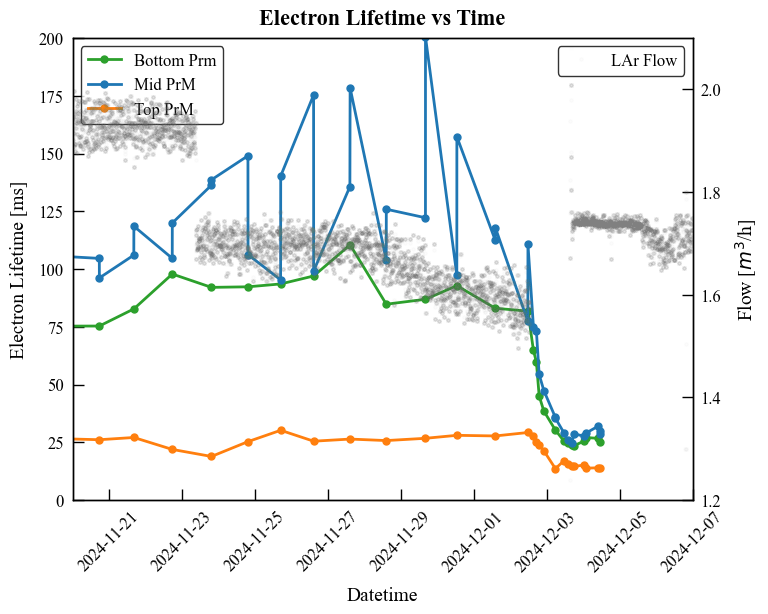

In [6]:
bot_purity = pd.read_csv("/Users/jcapo/cernbox/PDHDdata/prm_Bot_lifetime_data_calibration_database.csv", header=0)
bot_purity["Timestamp"] = pd.to_datetime(bot_purity["Timestamp"], format="%Y-%m-%d %H:%M:%S")
bot_purity = bot_purity.set_index("Timestamp")

mid_purity = pd.read_csv("/Users/jcapo/cernbox/PDHDdata/prm_Mid_lifetime_data_calibration_database.csv", header=0)
mid_purity["Timestamp"] = pd.to_datetime(mid_purity["Timestamp"], format="%Y-%m-%d %H:%M:%S")
mid_purity = mid_purity.set_index("Timestamp")

top_purity = pd.read_csv("/Users/jcapo/cernbox/PDHDdata/prm_Top_lifetime_data_calibration_database.csv", header=0)
top_purity["Timestamp"] = pd.to_datetime(top_purity["Timestamp"], format="%Y-%m-%d %H:%M:%S")
top_purity = top_purity.set_index("Timestamp")

fig, axes = plt.subplots(figsize=(8, 6))
axes.plot(bot_purity.index.values, bot_purity["EleLifeTime_TPCCenter"], "-o", label="Bottom Prm", color="tab:green")
axes.plot(mid_purity.index.values, mid_purity["EleLifeTime_TPCCenter"], "-o", label="Mid PrM", color="tab:blue")
axes.plot(top_purity.index.values, top_purity["EleLifeTime_TPCCenter"], "-o", label="Top PrM", color="tab:orange")
axes.set_ylim(0,200)
axes.set_xlim(datetime.datetime(2024, 11, 20), datetime.datetime(2024, 12, 7))
axes.set_xlabel("Datetime")
axes.set_ylabel("Electron Lifetime [ms]")
axes.set_title("Electron Lifetime vs Time")
axes.legend(loc="upper left")
axes.tick_params(axis='x', rotation=45)
axes2 = axes.twinx()
axes2.plot(lar_flow.data.index, lar_flow.data.values, ".", label="LAr Flow", color="gray", alpha=.025)
axes2.set_ylabel(fr"Flow [$m^3$/h]")
axes2.legend(loc="upper right")
axes2.set_ylim(1.2, 2.1)

(7500.0, 7700.0)

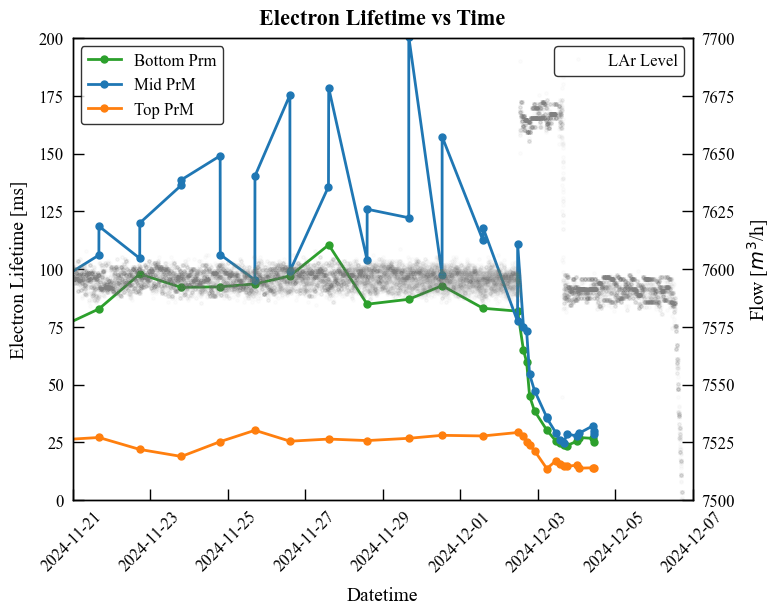

In [14]:
bot_purity = pd.read_csv("/Users/jcapo/cernbox/PDHDdata/prm_Bot_lifetime_data_calibration_database.csv", header=0)
bot_purity["Timestamp"] = pd.to_datetime(bot_purity["Timestamp"], format="%Y-%m-%d %H:%M:%S")
bot_purity = bot_purity.set_index("Timestamp")

mid_purity = pd.read_csv("/Users/jcapo/cernbox/PDHDdata/prm_Mid_lifetime_data_calibration_database.csv", header=0)
mid_purity["Timestamp"] = pd.to_datetime(mid_purity["Timestamp"], format="%Y-%m-%d %H:%M:%S")
mid_purity = mid_purity.set_index("Timestamp")

top_purity = pd.read_csv("/Users/jcapo/cernbox/PDHDdata/prm_Top_lifetime_data_calibration_database.csv", header=0)
top_purity["Timestamp"] = pd.to_datetime(top_purity["Timestamp"], format="%Y-%m-%d %H:%M:%S")
top_purity = top_purity.set_index("Timestamp")

fig, axes = plt.subplots(figsize=(8, 6))
axes.plot(bot_purity.index.values, bot_purity["EleLifeTime_TPCCenter"], "-o", label="Bottom Prm", color="tab:green")
axes.plot(mid_purity.index.values, mid_purity["EleLifeTime_TPCCenter"], "-o", label="Mid PrM", color="tab:blue")
axes.plot(top_purity.index.values, top_purity["EleLifeTime_TPCCenter"], "-o", label="Top PrM", color="tab:orange")
axes.set_ylim(0,200)
axes.set_xlim(datetime.datetime(2024, 11, 21), datetime.datetime(2024, 12, 7))
axes.set_xlabel("Datetime")
axes.set_ylabel("Electron Lifetime [ms]")
axes.set_title("Electron Lifetime vs Time")
axes.legend(loc="upper left")
axes.tick_params(axis='x', rotation=45)
axes2 = axes.twinx()
# axes2.plot(level2.data.index, cryostat_height*level2.data.values/100, ".", label="LAr Flow", color="gray", alpha=.025)
axes2.plot(level2.data.index, cryostat_height*level2.data.values/100, ".", label="LAr Level", color="gray", alpha=0.025)
axes2.set_ylabel(fr"Flow [$m^3$/h]")
axes2.legend(loc="upper right")
axes2.set_ylim(7500, 7700)

Text(0.5, 1.0, 'Cryostat and Ambient Pressure during Cryogenic Test')

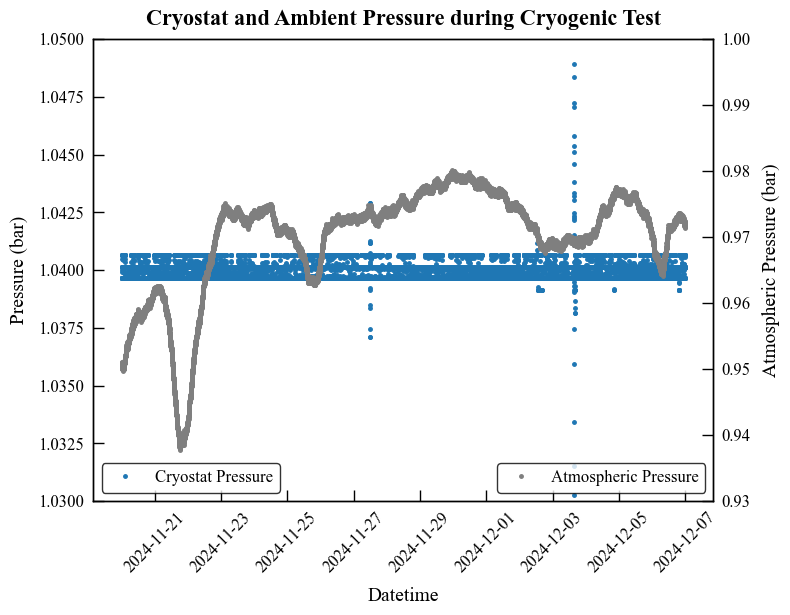

In [17]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(pressure1.data.index, pressure1.data.values, ".", label="Cryostat Pressure", color="tab:blue")
axes.set_ylim(1.03, 1.05)
axes2 = axes.twinx()
axes2.plot(ambient_pressure.data.index, ambient_pressure.data.values/1000, ".", label="Atmospheric Pressure", color="tab:gray", alpha=1)
axes2.set_ylim(0.93, 1.0)
axes2.set_ylabel("Atmospheric Pressure (bar)")
axes2.legend(loc="lower right")
axes.tick_params(axis='x', rotation=45)
axes.set_xlabel("Datetime")
axes.set_ylabel("Pressure (bar)")
axes.legend(loc="lower left")
axes.set_title("Cryostat and Ambient Pressure during Cryogenic Test")

Text(0.5, 1.0, 'Pump Differential Pressure and LAr Flow during Cryogenic Test')

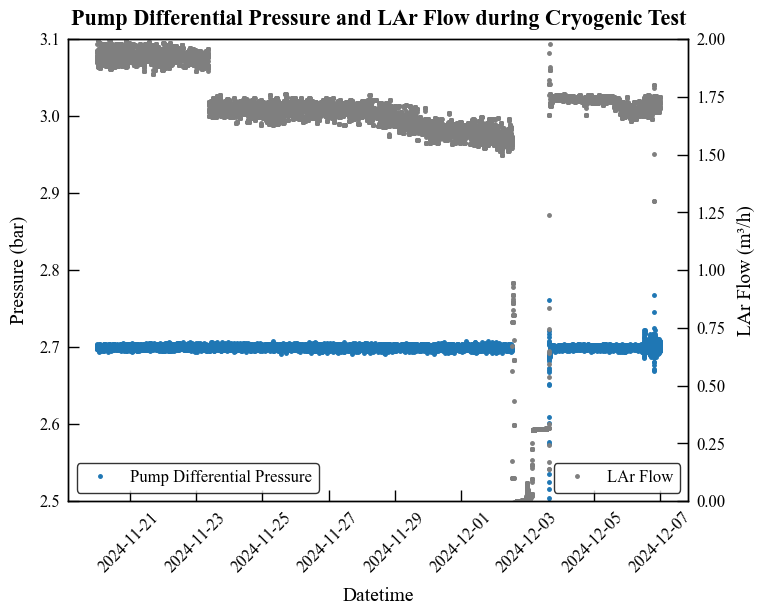

In [19]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(pump_pressure.data.index, pump_pressure.data.values, ".", label="Pump Differential Pressure", color="tab:blue")
axes.set_ylim(2.5, 3.1)
axes2 = axes.twinx()
axes2.plot(lar_flow.data.index, lar_flow.data.values, ".", label="LAr Flow", color="tab:gray", alpha=1)
axes2.set_ylim(0, 2.0)
axes2.set_ylabel("LAr Flow (m³/h)")
axes2.legend(loc="lower right")
axes.tick_params(axis='x', rotation=45)
axes.set_xlabel("Datetime")
axes.set_ylabel("Pressure (bar)")
axes.legend(loc="lower left")
axes.set_title("Pump Differential Pressure and LAr Flow during Cryogenic Test")

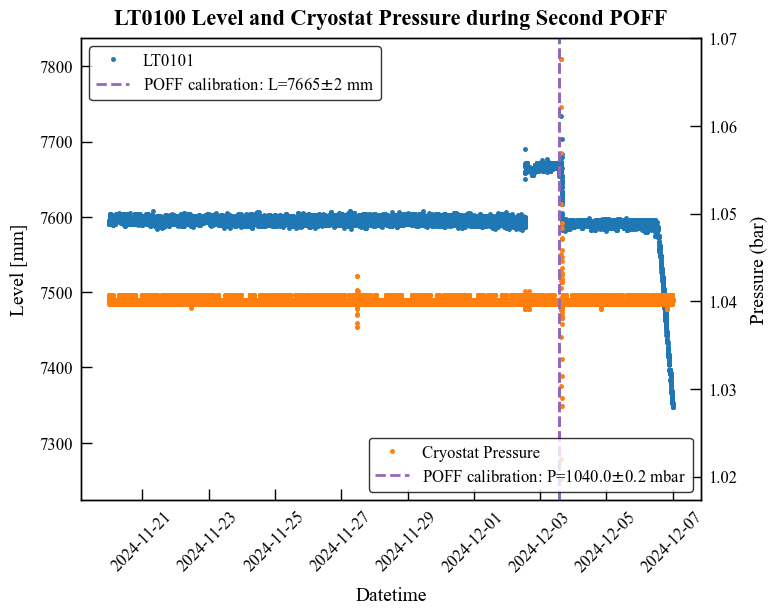

In [87]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(level2.data.index, cryostat_height*level2.data.values/100, ".", label="LT0101", color="tab:blue")
axes.set_xlabel("Datetime")
axes.set_ylabel("Level [mm]")
axes.tick_params(axis='x', rotation=45)
axes2 = axes.twinx()
axes2.plot(pressure1.data.index, pressure1.data.values, ".", label="Cryostat Pressure", color="tab:orange")
axes2.set_ylabel("Pressure (bar)")
axes.set_title("LT0100 Level and Cryostat Pressure during Second POFF")
axes.axvline(datetime.datetime(2024, 12, 3, 14, 0), color="tab:purple", linestyle="--", label=fr"POFF calibration: L={level2.data.loc[(level2.data.index > datetime.datetime(2024, 12, 3, 14, 0))&(level2.data.index<datetime.datetime(2024, 12, 3, 14, 30))].mean()*cryostat_height/100:.0f}$\pm${level2.data.loc[(level2.data.index > datetime.datetime(2024, 12, 3, 14, 0))&(level2.data.index<datetime.datetime(2024, 12, 3, 14, 30))].std()*cryostat_height/100:.0f} mm")
axes2.axvline(datetime.datetime(2024, 12, 3, 14, 0), color="tab:purple", linestyle="--", label=fr"POFF calibration: P={pressure1.data.loc[(pressure1.data.index > datetime.datetime(2024, 12, 3, 14, 0))&(pressure1.data.index<datetime.datetime(2024, 12, 3, 14, 30))].mean()*1000:.1f}$\pm${pressure1.data.loc[(pressure1.data.index > datetime.datetime(2024, 12, 3, 14, 0))&(pressure1.data.index<datetime.datetime(2024, 12, 3, 14, 30))].std()*1000:.1f} mbar")
axes.legend(loc="upper left")
axes2.legend(loc="lower right")
# axes.set_ylim(7550, 7650)

In [24]:
tgrad.calibrate(calibName="LAR2023_TREE_AVG")
apa.calibrate(calibName="SECOND_POFF_OCTOBER")
pump.calibrate(calibName="SECOND_POFF_OCTOBER")
prm.calibrate(calibName="SECOND_POFF_OCTOBER")
hawai.calibrate(calibName="SECOND_POFF_EMPTY")
pipe.calibrate(calibName="SECOND_POFF_OCTOBER")
wall.calibrate(calibName="SECOND_POFF_OCTOBER")
# ga1.calibrate(calibName="FIRST_POFF_PIPES")
# ga2.calibrate(calibName="FIRST_POFF_PIPES")

Equalizing TGRAD Sensors: 100%|██████████| 48/48 [00:05<00:00,  8.98sensor/s]
Calibrating TGRAD Sensors - Calibration Name: LAR2023_TREE_AVG:  50%|█████     | 24/48 [00:00<00:00, 112.26sensor/s]

ERROR: SensorID (99999) not found in calibration (LAR2023_TREE_AVG)


Calibrating TGRAD Sensors - Calibration Name: LAR2023_TREE_AVG: 100%|██████████| 48/48 [00:00<00:00, 107.78sensor/s]


ERROR: SensorID (40530) not found in calibration (LAR2023_TREE_AVG)
ERROR: SensorID (40529) not found in calibration (LAR2023_TREE_AVG)


Equalizing APA Sensors: 100%|██████████| 16/16 [00:01<00:00, 14.61sensor/s]
Calibrating APA Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 16/16 [00:00<00:00, 109.93sensor/s]
Equalizing PP Sensors: 100%|██████████| 2/2 [00:00<00:00, 10.48sensor/s]
Calibrating PP Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 2/2 [00:00<00:00, 89.63sensor/s]
Equalizing PRM Sensors: 100%|██████████| 6/6 [00:00<00:00,  9.26sensor/s]
Calibrating PRM Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 6/6 [00:00<00:00, 109.59sensor/s]
Equalizing HAWAI Sensors: 100%|██████████| 24/24 [00:02<00:00, 10.37sensor/s]
Calibrating HAWAI Sensors - Calibration Name: SECOND_POFF_EMPTY: 100%|██████████| 24/24 [00:00<00:00, 84.73sensor/s]
Equalizing PIPE Sensors: 100%|██████████| 12/12 [00:01<00:00,  7.96sensor/s]


ERROR: Channel (TE0120) not found


Calibrating PIPE Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 12/12 [00:00<00:00, 52.39sensor/s]
Equalizing WALL Sensors: 100%|██████████| 5/5 [00:00<00:00,  9.81sensor/s]
Calibrating WALL Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 5/5 [00:00<00:00, 54.88sensor/s]

ERROR: SensorID (40066) not found in calibration (SECOND_POFF_OCTOBER)
ERROR: SensorID (40067) not found in calibration (SECOND_POFF_OCTOBER)
ERROR: SensorID (40068) not found in calibration (SECOND_POFF_OCTOBER)
ERROR: SensorID (40069) not found in calibration (SECOND_POFF_OCTOBER)
ERROR: SensorID (40070) not found in calibration (SECOND_POFF_OCTOBER)


In [36]:
tgrad.calibrate(calibName="LN2023_TREE_AVG")

Equalizing TGRAD Sensors: 100%|██████████| 48/48 [00:05<00:00,  8.94sensor/s]
Calibrating TGRAD Sensors - Calibration Name: LN2023_TREE_AVG:  44%|████▍     | 21/48 [00:00<00:00, 102.55sensor/s]

ERROR: SensorID (99999) not found in calibration (LN2023_TREE_AVG)


Calibrating TGRAD Sensors - Calibration Name: LN2023_TREE_AVG: 100%|██████████| 48/48 [00:00<00:00, 100.45sensor/s]


Equalizing TGRAD Sensors: 100%|██████████| 48/48 [00:04<00:00,  9.96sensor/s]
Calibrating TGRAD Sensors - Calibration Name: LN2023_TREE_AVG:  46%|████▌     | 22/48 [00:00<00:00, 105.46sensor/s]

ERROR: SensorID (99999) not found in calibration (LN2023_TREE_AVG)


Calibrating TGRAD Sensors - Calibration Name: LN2023_TREE_AVG: 100%|██████████| 48/48 [00:00<00:00, 97.41sensor/s] 
Equalizing TGRAD Sensors: 100%|██████████| 48/48 [00:05<00:00,  8.64sensor/s]
Calibrating TGRAD Sensors - Calibration Name: LN2022_TREE_AVG:  15%|█▍        | 7/48 [00:00<00:00, 69.78sensor/s]

ERROR: SensorID (99999) not found in calibration (LN2022_TREE_AVG)


Calibrating TGRAD Sensors - Calibration Name: LN2022_TREE_AVG: 100%|██████████| 48/48 [00:01<00:00, 38.45sensor/s]


...

ERROR: SensorID (99999) not found in calibration (LAR2023_TREE_AVG)


Calibrating TGRAD Sensors - Calibration Name: LAR2023_TREE_AVG: 100%|██████████| 48/48 [00:00<00:00, 106.37sensor/s]


ERROR: SensorID (40530) not found in calibration (LAR2023_TREE_AVG)
ERROR: SensorID (40529) not found in calibration (LAR2023_TREE_AVG)


Equalizing TGRAD Sensors: 100%|██████████| 48/48 [00:05<00:00,  9.20sensor/s]
Calibrating TGRAD Sensors - Calibration Name: LAR2018_REF: 100%|██████████| 48/48 [00:00<00:00, 105.55sensor/s]


ERROR: SensorID (40530) not found in calibration (LAR2018_REF)
ERROR: SensorID (40529) not found in calibration (LAR2018_REF)


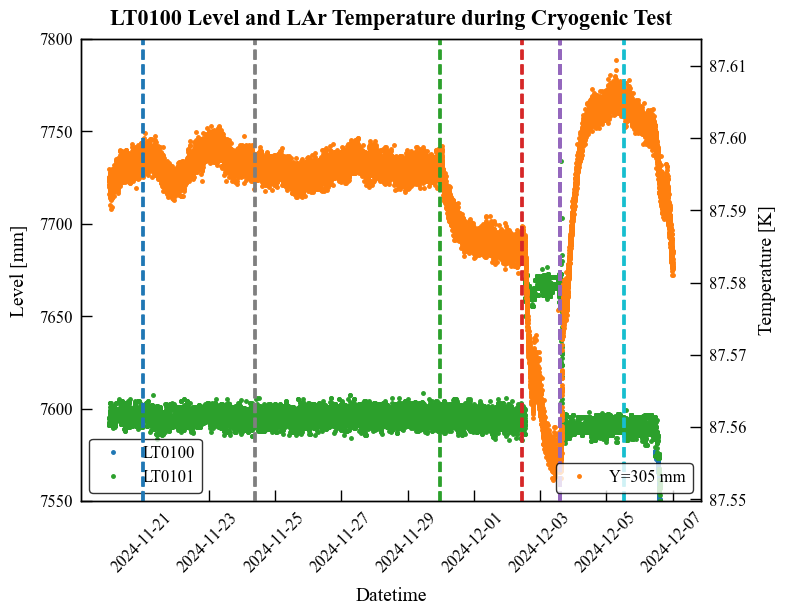

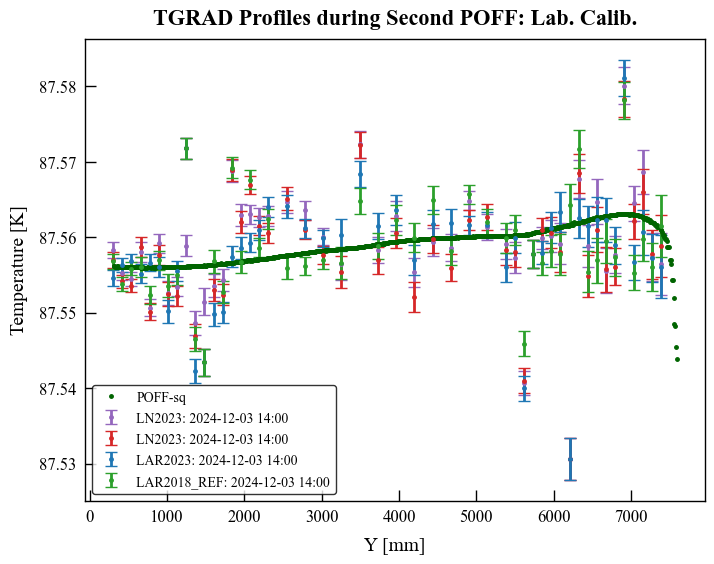

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(level1.data.index, level1.data.values, ".", label="LT0100", color="tab:blue")
axes.plot(level2.data.index, cryostat_height*level2.data.values/100, ".", label="LT0101", color="tab:green")
axes.legend(loc="lower left")
axes.set_xlabel("Datetime")
axes.set_ylabel("Level [mm]")
axes.set_ylim(7550, 7800)
axes2 = axes.twinx()
axes2.plot(tgrad.sensors[39607].data.index, tgrad.sensors[39607].data.values, ".", label=fr"Y={tgrad.sensors[39607].Y:.0f} mm", color="tab:orange")
axes2.legend(loc="lower right")
axes2.set_ylabel("Temperature [K]")
axes.set_title("LT0100 Level and LAr Temperature during Cryogenic Test")
axes.tick_params(axis='x', rotation=45)

fig, axes = plt.subplots(1, 1, figsize=(8, 6))
deltat = datetime.timedelta(minutes=30)
t1 = datetime.datetime(2024, 11, 21, 0)
tgrad.makeProfiles(tini=t1, tend=t1 + deltat)
axes2.axvline(t1, color="tab:blue", linestyle="--", label=f"Profile {t1.strftime('%Y-%m-%d %H:%M')}")
axes2.axvline(t1 + deltat, color="tab:blue", linestyle="--", label=f"Profile {t1.strftime('%Y-%m-%d %H:%M')} - {deltat}")
# axes.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values - tgrad.profiles["temp"].loc[(tgrad.profiles["Y"] == 305)].values[0], yerr=tgrad.profiles["err"].values, fmt=".", label=f"Profile {t1.strftime('%Y-%m-%d %H:%M')}", color="tab:blue")

t2 = datetime.datetime(2024, 11, 24, 9)
tgrad.makeProfiles(tini=t2, tend=t2 + deltat)
axes2.axvline(t2, color="tab:gray", linestyle="--", label=f"Profile {t2.strftime('%Y-%m-%d %H:%M')}")
axes2.axvline(t2 + deltat, color="tab:gray", linestyle="--", label=f"Profile {t2.strftime('%Y-%m-%d %H:%M')} - {deltat}")
# axes.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values - tgrad.profiles["temp"].loc[(tgrad.profiles["Y"] == 305)].values[0], yerr=tgrad.profiles["err"].values, fmt=".", label=f"Profile {t2.strftime('%Y-%m-%d %H:%M')}", color="tab:orange")

t3 = datetime.datetime(2024, 11, 29, 23)
tgrad.makeProfiles(tini=t3, tend=t3 + deltat)
axes2.axvline(t3, color="tab:green", linestyle="--", label=f"Profile {t3.strftime('%Y-%m-%d %H:%M')}")
axes2.axvline(t3 + deltat, color="tab:green", linestyle="--", label=f"Profile {t3.strftime('%Y-%m-%d %H:%M')} - {deltat}")
# axes.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values - tgrad.profiles["temp"].loc[(tgrad.profiles["Y"] == 305)].values[0], yerr=tgrad.profiles["err"].values, fmt=".", label=f"Profile {t3.strftime('%Y-%m-%d %H:%M')}", color="tab:green")

t4 = datetime.datetime(2024, 12, 2, 10)
tgrad.makeProfiles(tini=t4, tend=t4 + deltat)
axes2.axvline(t4, color="tab:red", linestyle="--", label=f"Profile {t4.strftime('%Y-%m-%d %H:%M')}")
axes2.axvline(t4 + deltat, color="tab:red", linestyle="--", label=f"Profile {t4.strftime('%Y-%m-%d %H:%M')} - {deltat}")
# axes.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values - tgrad.profiles["temp"].loc[(tgrad.profiles["Y"] == 305)].values[0], yerr=tgrad.profiles["err"].values, fmt=".", label=f"Profile {t4.strftime('%Y-%m-%d %H:%M')}", color="tab:red")

tgrad.calibrate(calibName="LN2023_TREE_AVG")
t5 = datetime.datetime(2024, 12, 3, 14)
tgrad.makeProfiles(tini=t5, tend=t5 + deltat)
axes2.axvline(t5, color="tab:purple", linestyle="--", label=f"Profile {t5.strftime('%Y-%m-%d %H:%M')}")
axes2.axvline(t5 + deltat, color="tab:purple", linestyle="--", label=f"Profile {t5.strftime('%Y-%m-%d %H:%M')} - {deltat}")
axes.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values, yerr=tgrad.profiles["err"].values, fmt=".", label=f"LN2023: {t5.strftime('%Y-%m-%d %H:%M')}", color="tab:purple")
ln23_profiles = tgrad.profiles.set_index("Y")
tgrad.calibrate(calibName="LN2022_TREE_AVG")
tgrad.makeProfiles(tini=t5, tend=t5 + deltat)
axes2.axvline(t5, color="tab:purple", linestyle="--", label=f"Profile {t5.strftime('%Y-%m-%d %H:%M')}")
axes2.axvline(t5 + deltat, color="tab:purple", linestyle="--", label=f"Profile {t5.strftime('%Y-%m-%d %H:%M')} - {deltat}")
axes.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values, yerr=tgrad.profiles["err"].values, fmt=".", label=f"LN2023: {t5.strftime('%Y-%m-%d %H:%M')}", color="tab:red")
ln22_profiles = tgrad.profiles.set_index("Y")
tgrad.calibrate(calibName="LAR2023_TREE_AVG")
tgrad.makeProfiles(tini=t5, tend=t5 + deltat)
axes2.axvline(t5, color="tab:purple", linestyle="--", label=f"Profile {t5.strftime('%Y-%m-%d %H:%M')}")
axes2.axvline(t5 + deltat, color="tab:purple", linestyle="--", label=f"Profile {t5.strftime('%Y-%m-%d %H:%M')} - {deltat}")
axes.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values, yerr=tgrad.profiles["err"].values, fmt=".", label=f"LAR2023: {t5.strftime('%Y-%m-%d %H:%M')}", color="tab:blue")
lar23_profiles = tgrad.profiles.set_index("Y")
tgrad.calibrate(calibName="LAR2018_REF")
tgrad.makeProfiles(tini=t5, tend=t5 + deltat)
axes2.axvline(t5, color="tab:purple", linestyle="--", label=f"Profile {t5.strftime('%Y-%m-%d %H:%M')}")
axes2.axvline(t5 + deltat, color="tab:purple", linestyle="--", label=f"Profile {t5.strftime('%Y-%m-%d %H:%M')} - {deltat}")
axes.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values, yerr=tgrad.profiles["err"].values, fmt=".", label=f"LAR2018_REF: {t5.strftime('%Y-%m-%d %H:%M')}", color="tab:green")
lar18_profiles = tgrad.profiles.set_index("Y")

merged_profiles = ln23_profiles.join(
    ln22_profiles,
    lsuffix="_ln23",
    rsuffix="_ln22",
    how="inner"
).join(
    lar23_profiles,
    rsuffix="_lar23",
    how="inner"
).join(
    lar18_profiles,
    rsuffix="_lar18",
    how="inner"
)


t6 = datetime.datetime(2024, 12, 5, 12)
tgrad.makeProfiles(tini=t6, tend=t6 + deltat)
axes2.axvline(t6, color="tab:cyan", linestyle="--", label=f"Profile {t6.strftime('%Y-%m-%d %H:%M')}")
axes2.axvline(t6 + deltat, color="tab:cyan", linestyle="--", label=f"Profile {t6.strftime('%Y-%m-%d %H:%M')} - {deltat}")
# axes.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values - tgrad.profiles["temp"].loc[(tgrad.profiles["Y"] == 305)].values[0], yerr=tgrad.profiles["err"].values, fmt=".", label=f"Profile {t6.strftime('%Y-%m-%d %H:%M')}", color="tab:cyan")

cfd = pd.read_csv("/Users/jcapo/cernbox/PDHDdata/CFD/VMBasePD2-square.csv", header=0, names=["Y", "temp"], index_col=0)
cfd_poff = pd.read_csv("/Users/jcapo/cernbox/PDHDdata/CFD/VMOFF-square.csv", header=0, names=["Y", "temp"], index_col=0)
# axes.plot(1e3*cfd.loc[(1e3*cfd.index>300)].index.values, cfd.loc[(1e3*cfd.index>300)]["temp"].values - 0.025, '.', label=fr'PON-Sq', color="tab:green")
axes.plot(1e3*cfd_poff.loc[(1e3*cfd_poff.index>300)].index.values, cfd_poff.loc[(1e3*cfd_poff.index>300)]["temp"].values - 0.025, '.', label=fr'POFF-sq', color="darkgreen")

axes.set_xlabel("Y [mm]")
axes.set_ylabel("Temperature [K]")
axes.set_title("TGRAD Profiles during Second POFF: Lab. Calib.")
axes.legend(loc="best", ncol=1, fontsize="small")

In [57]:
print(merged_profiles.columns)

Index(['X_ln23', 'Z_ln23', 'name_ln23', 'temp_ln23', 'err_ln23', 'X_ln22',
       'Z_ln22', 'name_ln22', 'temp_ln22', 'err_ln22', 'X', 'Z', 'name',
       'temp', 'err', 'X_lar18', 'Z_lar18', 'name_lar18', 'temp_lar18',
       'err_lar18'],
      dtype='object')


In [68]:
avg_temp = merged_profiles[["temp_ln22", "temp_ln23", "temp", "temp_lar18"]].mean(axis=1)
err_temp = merged_profiles[["temp_ln22", "temp_ln23", "temp", "temp_lar18"]].std(axis=1)

Text(0.5, 1.0, 'TGRAD Profiles during Second POFF: Average Calib.')

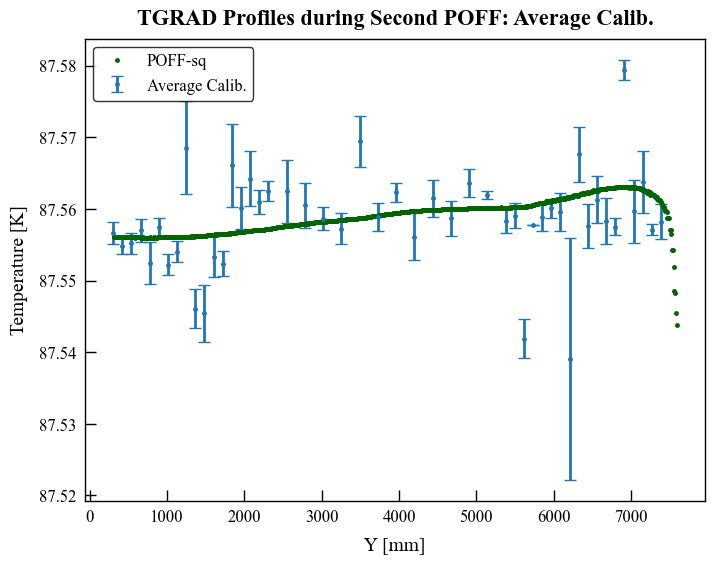

In [72]:
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.errorbar(avg_temp.index, avg_temp.values, yerr=err_temp.values, fmt=".", label="Average Calib.", color="tab:blue")
cfd = pd.read_csv("/Users/jcapo/cernbox/PDHDdata/CFD/VMBasePD2-square.csv", header=0, names=["Y", "temp"], index_col=0)
cfd_poff = pd.read_csv("/Users/jcapo/cernbox/PDHDdata/CFD/VMOFF-square.csv", header=0, names=["Y", "temp"], index_col=0)
axes.plot(1e3*cfd_poff.loc[(1e3*cfd_poff.index>300)].index.values, cfd_poff.loc[(1e3*cfd_poff.index>300)]["temp"].values - 0.025, '.', label=fr'POFF-sq', color="darkgreen")
axes.legend(loc="best", ncol=1)
axes.set_xlabel("Y [mm]")
axes.set_ylabel("Temperature [K]")
axes.set_title("TGRAD Profiles during Second POFF: Average Calib.")

In [139]:
tgrad.calibrate(calibName="SECOND_POFF_EMPTY")
apa.calibrate(calibName="SECOND_POFF_OCTOBER")
pump.calibrate(calibName="SECOND_POFF_OCTOBER")
prm.calibrate(calibName="SECOND_POFF_OCTOBER")
hawai.calibrate(calibName="SECOND_POFF_EMPTY")
pipe.calibrate(calibName="SECOND_POFF_OCTOBER")
wall.calibrate(calibName="SECOND_POFF_OCTOBER")
# ga1.calibrate(calibName="FIRST_POFF_PIPES")
# ga2.calibrate(calibName="FIRST_POFF_PIPES")

Equalizing TGRAD Sensors: 100%|██████████| 48/48 [00:04<00:00, 10.00sensor/s]
Calibrating TGRAD Sensors - Calibration Name: SECOND_POFF_EMPTY: 100%|██████████| 48/48 [00:00<00:00, 105.67sensor/s]
Equalizing APA Sensors: 100%|██████████| 16/16 [00:01<00:00, 14.85sensor/s]
Calibrating APA Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 16/16 [00:00<00:00, 103.82sensor/s]
Equalizing PP Sensors: 100%|██████████| 2/2 [00:00<00:00, 11.11sensor/s]
Calibrating PP Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 2/2 [00:00<00:00, 100.34sensor/s]
Equalizing PRM Sensors: 100%|██████████| 6/6 [00:00<00:00, 10.15sensor/s]
Calibrating PRM Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 6/6 [00:00<00:00, 77.81sensor/s]
Equalizing HAWAI Sensors: 100%|██████████| 24/24 [00:02<00:00, 11.80sensor/s]
Calibrating HAWAI Sensors - Calibration Name: SECOND_POFF_EMPTY: 100%|██████████| 24/24 [00:00<00:00, 109.73sensor/s]
Equalizing PIPE Sensors: 100%|███████

ERROR: Channel (TE0120) not found


Calibrating PIPE Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 12/12 [00:00<00:00, 108.97sensor/s]
Equalizing WALL Sensors: 100%|██████████| 5/5 [00:00<00:00, 10.50sensor/s]
Calibrating WALL Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 5/5 [00:00<00:00, 108.96sensor/s]

ERROR: SensorID (40066) not found in calibration (SECOND_POFF_OCTOBER)
ERROR: SensorID (40067) not found in calibration (SECOND_POFF_OCTOBER)
ERROR: SensorID (40068) not found in calibration (SECOND_POFF_OCTOBER)
ERROR: SensorID (40069) not found in calibration (SECOND_POFF_OCTOBER)
ERROR: SensorID (40070) not found in calibration (SECOND_POFF_OCTOBER)


Equalizing APA Sensors: 100%|██████████| 16/16 [00:01<00:00, 14.12sensor/s]
Calibrating APA Sensors - Calibration Name: SECOND_POFF_EMPTY: 100%|██████████| 16/16 [00:00<00:00, 97.18sensor/s] 


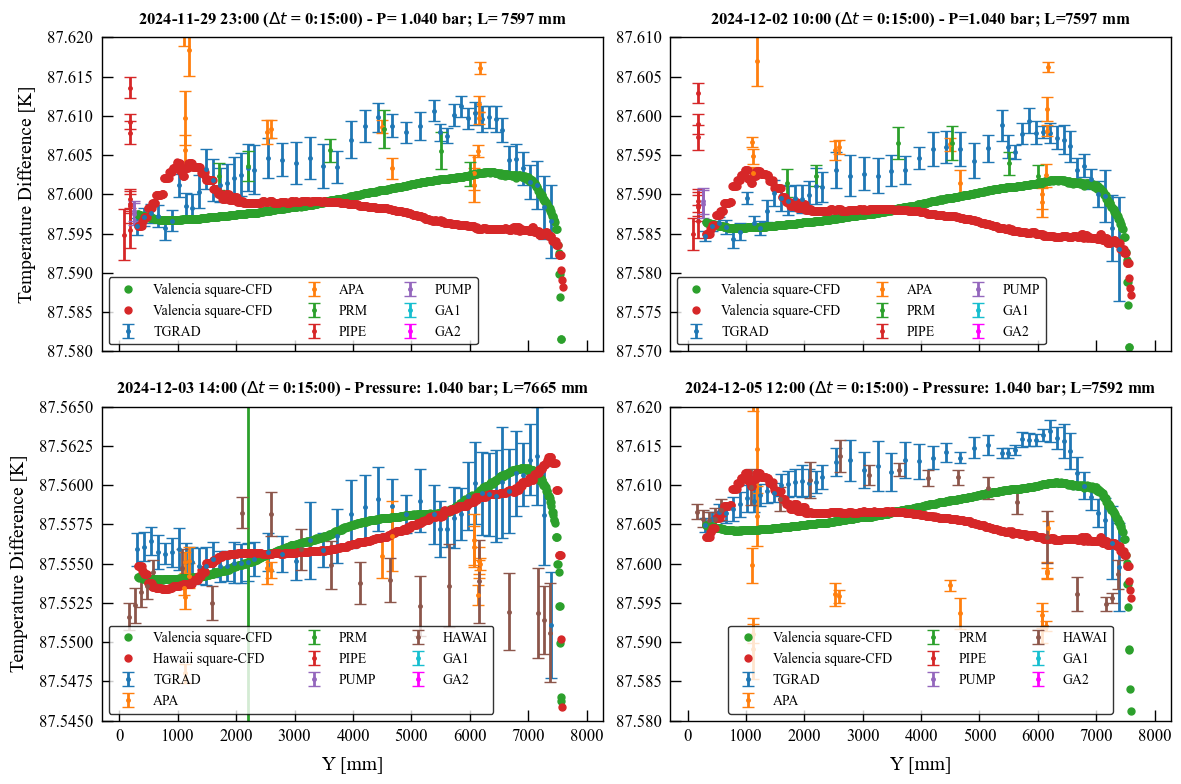

In [140]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=False)
axes = axes.flatten()
deltat = datetime.timedelta(minutes=15)
# t1 = datetime.datetime(2024, 5, 13, 9)
tgrad.makeProfiles(tini=t1, tend=t1 + deltat)
ref_tgrad_profile = tgrad.profiles
apa.makeProfiles(tini=t1, tend=t1 + deltat)
ref_apa_profile = apa.profiles
prm.makeProfiles(tini=t1, tend=t1 + deltat)
ref_prm_profile = prm.profiles
pipe.makeProfiles(tini=t1, tend=t1 + deltat)
ref_pipe_profile = pipe.profiles
pump.makeProfiles(tini=t1, tend=t1 + deltat)
ref_pump_profile = pump.profiles
hawai.makeProfiles(tini=t1, tend=t1 + deltat)
ref_hawai_profile = hawai.profiles
ga1.makeProfiles(tini=t1, tend=t1 + deltat)
ref_ga1_profile = ga1.profiles
ga2.makeProfiles(tini=t1, tend=t1 + deltat)
ref_ga2_profile = ga2.profiles
wall.makeProfiles(tini=t1, tend=t1 + deltat)
ref_wall_profile = wall.profiles

# t3 = datetime.datetime(2024, 5, 15, 9)
tgrad.makeProfiles(tini=t3, tend=t3 + deltat)
current_tgrad_profile = tgrad.profiles
axes[0].errorbar(current_tgrad_profile["Y"].values, (current_tgrad_profile["temp"]).values  , yerr=np.sqrt(current_tgrad_profile["err"].values**2), fmt=".", label=f"TGRAD", color="tab:blue")
apa.makeProfiles(tini=t3, tend=t3 + deltat)
current_apa_profile = apa.profiles
axes[0].errorbar(current_apa_profile["Y"].values, (current_apa_profile["temp"]).values , yerr=np.sqrt(current_apa_profile["err"].values**2), fmt=".", label=f"APA", color="tab:orange")
prm.makeProfiles(tini=t3, tend=t3 + deltat)
current_prm_profile = prm.profiles
axes[0].errorbar(current_prm_profile["Y"].values, (current_prm_profile["temp"]).values , yerr=np.sqrt(current_prm_profile["err"].values**2), fmt=".", label=f"PRM", color="tab:green")
pipe.makeProfiles(tini=t3, tend=t3 + deltat)
current_pipe_profile = pipe.profiles
axes[0].errorbar(current_pipe_profile["Y"].values, (current_pipe_profile["temp"]).values , yerr=np.sqrt(current_pipe_profile["err"].values**2), fmt=".", label=f"PIPE", color="tab:red")
pump.makeProfiles(tini=t3, tend=t3 + deltat)
current_pump_profile = pump.profiles
axes[0].errorbar(current_pump_profile["Y"].values, (current_pump_profile["temp"]).values , yerr=np.sqrt(current_pump_profile["err"].values**2), fmt=".", label=f"PUMP", color="tab:purple")
hawai.makeProfiles(tini=t3, tend=t3 + deltat)
current_hawai_profile = hawai.profiles
# axes[0].errorbar(current_hawai_profile["Y"].values, (current_hawai_profile["temp"]).values , yerr=np.sqrt(current_hawai_profile["err"].values**2), fmt=".", label=f"HAWAI", color="tab:brown")
ga1.makeProfiles(tini=t3, tend=t3 + deltat)
current_ga1_profile = ga1.profiles
axes[0].errorbar(current_ga1_profile["Y"].values, (current_ga1_profile["temp"]).values , yerr=np.sqrt(current_ga1_profile["err"].values**2), fmt=".", label=f"GA1", color="tab:cyan")
ga2.makeProfiles(tini=t3, tend=t3 + deltat)
current_ga2_profile = ga2.profiles
axes[0].errorbar(current_ga2_profile["Y"].values, (current_ga2_profile["temp"]).values , yerr=np.sqrt(current_ga2_profile["err"].values**2), fmt=".", label=f"GA2", color="magenta")
wall.makeProfiles(tini=t3, tend=t3 + deltat)
current_wall_profile = wall.profiles
# axes[0].errorbar(current_wall_profile["Y"].values, (current_wall_profile["temp"]).values , yerr=np.sqrt(current_wall_profile["err"].values**2), fmt=".", label=f"WALL", color="tab:gray")

cfd = pd.read_csv("/Users/jcapo/cernbox/PDHDdata/CFD/VMBasePD2-square.csv", header=0, names=["Y", "temp"], index_col=0)
cfd_poff = pd.read_csv("/Users/jcapo/cernbox/PDHDdata/CFD/VMOFF-square.csv", header=0, names=["Y", "temp"], index_col=0)
axes[0].plot(1e3*cfd.loc[(1e3*cfd.index>300)].index.values, cfd.loc[(1e3*cfd.index>300)]["temp"].values + 0.003, 'o', label=fr'Valencia square-CFD', color="tab:green")
cfd = pd.read_csv("/Users/jcapo/cernbox/PDHDdata/CFD/HMBasePD2-square.csv", header=0, names=["Y", "temp"], index_col=0)
cfd_poff = pd.read_csv("/Users/jcapo/cernbox/PDHDdata/CFD/HMOFF-square.csv", header=0, names=["Y", "temp"], index_col=0)
axes[0].plot(1e3*cfd.loc[(1e3*cfd.index>300)].index.values, 0.003 + (cfd.loc[(1e3*cfd.index>300)]["temp"] - cfd_poff.loc[(1e3*cfd.index>300)]["temp"] + cfd_poff.loc[(1e3*cfd.index>300)]["temp"].mean()).values, 'o', label=fr'Valencia square-CFD', color="tab:red")

# t4 = datetime.datetime(2024, 5, 16, 9)
tgrad.makeProfiles(tini=t4, tend=t4 + deltat)
current_tgrad_profile = tgrad.profiles
axes[1].errorbar(current_tgrad_profile["Y"].values, (current_tgrad_profile["temp"]).values , yerr=np.sqrt(current_tgrad_profile["err"].values**2), fmt=".", label=f"TGRAD", color="tab:blue")
apa.makeProfiles(tini=t4, tend=t4 + deltat)
current_apa_profile = apa.profiles
axes[1].errorbar(current_apa_profile["Y"].values, (current_apa_profile["temp"]).values , yerr=np.sqrt(current_apa_profile["err"].values**2), fmt=".", label=f"APA", color="tab:orange")
prm.makeProfiles(tini=t4, tend=t4 + deltat)
current_prm_profile = prm.profiles
axes[1].errorbar(current_prm_profile["Y"].values, (current_prm_profile["temp"]).values , yerr=np.sqrt(current_prm_profile["err"].values**2), fmt=".", label=f"PRM", color="tab:green")
pipe.makeProfiles(tini=t4, tend=t4 + deltat)
current_pipe_profile = pipe.profiles
axes[1].errorbar(current_pipe_profile["Y"].values, (current_pipe_profile["temp"]).values , yerr=np.sqrt(current_pipe_profile["err"].values**2), fmt=".", label=f"PIPE", color="tab:red");
pump.makeProfiles(tini=t4, tend=t4 + deltat)
current_pump_profile = pump.profiles
axes[1].errorbar(current_pump_profile["Y"].values, (current_pump_profile["temp"]).values , yerr=np.sqrt(current_pump_profile["err"].values**2), fmt=".", label=f"PUMP", color="tab:purple");
hawai.makeProfiles(tini=t4, tend=t4 + deltat)
current_hawai_profile = hawai.profiles
# axes[1].errorbar(current_hawai_profile["Y"].values, (current_hawai_profile["temp"]).values , yerr=np.sqrt(current_hawai_profile["err"].values**2), fmt=".", label=f"HAWAI", color="tab:brown")
ga1.makeProfiles(tini=t4, tend=t4 + deltat)
current_ga1_profile = ga1.profiles
axes[1].errorbar(current_ga1_profile["Y"].values, (current_ga1_profile["temp"]).values , yerr=np.sqrt(current_ga1_profile["err"].values**2), fmt=".", label=f"GA1", color="tab:cyan")
ga2.makeProfiles(tini=t4, tend=t4 + deltat)
current_ga2_profile = ga2.profiles
axes[1].errorbar(current_ga2_profile["Y"].values, (current_ga2_profile["temp"]).values , yerr=np.sqrt(current_ga2_profile["err"].values**2), fmt=".", label=f"GA2", color="magenta")
wall.makeProfiles(tini=t4, tend=t4 + deltat)
current_wall_profile = wall.profiles
# axes[1].errorbar(current_wall_profile["Y"].values, (current_wall_profile["temp"]).values , yerr=np.sqrt(current_wall_profile["err"].values**2), fmt=".", label=f"WALL", color="tab:gray")

cfd = pd.read_csv("/Users/jcapo/cernbox/PDHDdata/CFD/VMBasePD2-square.csv", header=0, names=["Y", "temp"], index_col=0)
cfd_poff = pd.read_csv("/Users/jcapo/cernbox/PDHDdata/CFD/VMOFF-square.csv", header=0, names=["Y", "temp"], index_col=0)
axes[1].plot(1e3*cfd.loc[(1e3*cfd.index>300)].index.values, cfd.loc[(1e3*cfd.index>300)]["temp"].values - 0.008, 'o', label=fr'Valencia square-CFD', color="tab:green")
cfd = pd.read_csv("/Users/jcapo/cernbox/PDHDdata/CFD/HMBasePD2-square.csv", header=0, names=["Y", "temp"], index_col=0)
cfd_poff = pd.read_csv("/Users/jcapo/cernbox/PDHDdata/CFD/HMOFF-square.csv", header=0, names=["Y", "temp"], index_col=0)
axes[1].plot(1e3*cfd.loc[(1e3*cfd.index>300)].index.values, (cfd.loc[(1e3*cfd.index>300)]["temp"] - cfd_poff.loc[(1e3*cfd.index>300)]["temp"] + cfd_poff.loc[(1e3*cfd.index>300)]["temp"].mean()).values - 0.008, 'o', label=fr'Valencia square-CFD', color="tab:red")

# t5 = datetime.datetime(2024, 5, 17, 12)
apa.calibrate(calibName="SECOND_POFF_EMPTY")
tgrad.makeProfiles(tini=t5, tend=t5 + deltat)
current_tgrad_profile = tgrad.profiles
axes[2].errorbar(current_tgrad_profile["Y"].values, (current_tgrad_profile["temp"]).values , yerr=np.sqrt(current_tgrad_profile["err"].values**2), fmt=".", label=f"TGRAD", color="tab:blue")
apa.makeProfiles(tini=t5, tend=t5 + deltat)
current_apa_profile = apa.profiles
axes[2].errorbar(current_apa_profile["Y"].values, (current_apa_profile["temp"]).values , yerr=np.sqrt(current_apa_profile["err"].values**2), fmt=".", label=f"APA", color="tab:orange")
prm.makeProfiles(tini=t5, tend=t5 + deltat)
current_prm_profile = prm.profiles
axes[2].errorbar(current_prm_profile["Y"].values, (current_prm_profile["temp"]).values , yerr=np.sqrt(current_prm_profile["err"].values**2), fmt=".", label=f"PRM", color="tab:green")
pipe.makeProfiles(tini=t5, tend=t5 + deltat)
current_pipe_profile = pipe.profiles
axes[2].errorbar(current_pipe_profile["Y"].values, (current_pipe_profile["temp"]).values , yerr=np.sqrt(current_pipe_profile["err"].values**2), fmt=".", label=f"PIPE", color="tab:red")
pump.makeProfiles(tini=t5, tend=t5 + deltat)
current_pump_profile = pump.profiles
axes[2].errorbar(current_pump_profile["Y"].values, (current_pump_profile["temp"]).values , yerr=np.sqrt(current_pump_profile["err"].values**2), fmt=".", label=f"PUMP", color="tab:purple");
hawai.makeProfiles(tini=t5, tend=t5 + deltat)
current_hawai_profile = hawai.profiles
axes[2].errorbar(current_hawai_profile["Y"].values, (current_hawai_profile["temp"]).values , yerr=np.sqrt(current_hawai_profile["err"].values**2), fmt=".", label=f"HAWAI", color="tab:brown")
ga1.makeProfiles(tini=t5, tend=t5 + deltat)
current_ga1_profile = ga1.profiles
axes[2].errorbar(current_ga1_profile["Y"].values, (current_ga1_profile["temp"]).values , yerr=np.sqrt(current_ga1_profile["err"].values**2), fmt=".", label=f"GA1", color="tab:cyan")
ga2.makeProfiles(tini=t5, tend=t5 + deltat)
current_ga2_profile = ga2.profiles
axes[2].errorbar(current_ga2_profile["Y"].values, (current_ga2_profile["temp"]).values , yerr=np.sqrt(current_ga2_profile["err"].values**2), fmt=".", label=f"GA2", color="magenta")
wall.makeProfiles(tini=t5, tend=t5 + deltat)
current_wall_profile = wall.profiles
# axes[2].errorbar(current_wall_profile["Y"].values, (current_wall_profile["temp"]).values , yerr=np.sqrt(current_wall_profile["err"].values**2), fmt=".", label=f"WALL", color="tab:gray")

cfd = pd.read_csv("/Users/jcapo/cernbox/PDHDdata/CFD/VMBasePD2-square.csv", header=0, names=["Y", "temp"], index_col=0)
cfd_poff = pd.read_csv("/Users/jcapo/cernbox/PDHDdata/CFD/VMOFF-square.csv", header=0, names=["Y", "temp"], index_col=0)
# axes[2].plot(1e3*cfd.loc[(1e3*cfd.index>300)].index.values, cfd.loc[(1e3*cfd.index>300)]["temp"].values - 0.035, 'o', label=fr'Valencia square-CFD', color="tab:green")
axes[2].plot(1e3*cfd_poff.loc[(1e3*cfd_poff.index>300)].index.values, cfd_poff.loc[(1e3*cfd_poff.index>300)]["temp"].values - 0.027, 'o', label=fr'Valencia square-CFD', color="tab:green")
cfd = pd.read_csv("/Users/jcapo/cernbox/PDHDdata/CFD/HMBasePD2-square.csv", header=0, names=["Y", "temp"], index_col=0)
cfd_poff = pd.read_csv("/Users/jcapo/cernbox/PDHDdata/CFD/HMOFF-square.csv", header=0, names=["Y", "temp"], index_col=0)
# axes[2].plot(1e3*cfd.loc[(1e3*cfd.index>300)].index.values, (cfd.loc[(1e3*cfd.index>300)]["temp"] - cfd_poff.loc[(1e3*cfd.index>300)]["temp"] + cfd_poff.loc[(1e3*cfd.index>300)]["temp"].mean()).values - 0.040, 'o', label=fr'Valencia square-CFD', color="tab:red")
axes[2].plot(1e3*cfd_poff.loc[(1e3*cfd_poff.index>300)].index.values, cfd_poff.loc[(1e3*cfd_poff.index>300)]["temp"].values - 0.027, 'o', label=fr'Hawaii square-CFD', color="tab:red")

# t6 = datetime.datetime(2024, 5, 19, 12)
tgrad.makeProfiles(tini=t6, tend=t6 + deltat)
current_tgrad_profile = tgrad.profiles
axes[3].errorbar(current_tgrad_profile["Y"].values, (current_tgrad_profile["temp"]).values , yerr=np.sqrt(current_tgrad_profile["err"].values**2), fmt=".", label=f"TGRAD", color="tab:blue")
apa.makeProfiles(tini=t6, tend=t6 + deltat)
current_apa_profile = apa.profiles
axes[3].errorbar(current_apa_profile["Y"].values, (current_apa_profile["temp"]).values , yerr=np.sqrt(current_apa_profile["err"].values**2), fmt=".", label=f"APA", color="tab:orange")
prm.makeProfiles(tini=t6, tend=t6 + deltat)
current_prm_profile = prm.profiles
axes[3].errorbar(current_prm_profile["Y"].values, (current_prm_profile["temp"]).values, yerr=np.sqrt(current_prm_profile["err"].values**2), fmt=".", label=f"PRM", color="tab:green")
pipe.makeProfiles(tini=t6, tend=t6 + deltat)
current_pipe_profile = pipe.profiles
axes[3].errorbar(current_pipe_profile["Y"].values, (current_pipe_profile["temp"]).values, yerr=np.sqrt(current_pipe_profile["err"].values**2), fmt=".", label=f"PIPE", color="tab:red")
pump.makeProfiles(tini=t6, tend=t6 + deltat)
current_pump_profile = pump.profiles
axes[3].errorbar(current_pump_profile["Y"].values, (current_pump_profile["temp"]).values, yerr=np.sqrt(current_pump_profile["err"].values**2), fmt=".", label=f"PUMP", color="tab:purple");
hawai.makeProfiles(tini=t6, tend=t6 + deltat)
current_hawai_profile = hawai.profiles
axes[3].errorbar(current_hawai_profile["Y"].values, (current_hawai_profile["temp"]).values , yerr=np.sqrt(current_hawai_profile["err"].values**2), fmt=".", label=f"HAWAI", color="tab:brown")
ga1.makeProfiles(tini=t6, tend=t6 + deltat)
current_ga1_profile = ga1.profiles
axes[3].errorbar(current_ga1_profile["Y"].values, (current_ga1_profile["temp"]).values , yerr=np.sqrt(current_ga1_profile["err"].values**2), fmt=".", label=f"GA1", color="tab:cyan")
ga2.makeProfiles(tini=t6, tend=t6 + deltat)
current_ga2_profile = ga2.profiles
axes[3].errorbar(current_ga2_profile["Y"].values, (current_ga2_profile["temp"]).values , yerr=np.sqrt(current_ga2_profile["err"].values**2), fmt=".", label=f"GA2", color="magenta")
wall.makeProfiles(tini=t6, tend=t6 + deltat)
current_wall_profile = wall.profiles
# axes[3].errorbar(current_wall_profile["Y"].values, (current_wall_profile["temp"]).values , yerr=np.sqrt(current_wall_profile["err"].values**2), fmt=".", label=f"WALL", color="tab:gray")

cfd = pd.read_csv("/Users/jcapo/cernbox/PDHDdata/CFD/VMBasePD2-square.csv", header=0, names=["Y", "temp"], index_col=0)
cfd_poff = pd.read_csv("/Users/jcapo/cernbox/PDHDdata/CFD/VMOFF-square.csv", header=0, names=["Y", "temp"], index_col=0)
axes[3].plot(1e3*cfd.loc[(1e3*cfd.index>300)].index.values, cfd.loc[(1e3*cfd.index>300)]["temp"].values + 0.0105, 'o', label=fr'Valencia square-CFD', color="tab:green")
cfd = pd.read_csv("/Users/jcapo/cernbox/PDHDdata/CFD/HMBasePD2-square.csv", header=0, names=["Y", "temp"], index_col=0)
cfd_poff = pd.read_csv("/Users/jcapo/cernbox/PDHDdata/CFD/HMOFF-square.csv", header=0, names=["Y", "temp"], index_col=0)
axes[3].plot(1e3*cfd.loc[(1e3*cfd.index>300)].index.values, (cfd.loc[(1e3*cfd.index>300)]["temp"] - cfd_poff.loc[(1e3*cfd.index>300)]["temp"] + cfd_poff.loc[(1e3*cfd.index>300)]["temp"].mean()).values + 0.0105, 'o', label=fr'Valencia square-CFD', color="tab:red")

p1 = pressure1.data.loc[(pressure1.data.index >= t1) & (pressure1.data.index < t1 + deltat)].mean()
p3 = pressure1.data.loc[(pressure1.data.index >= t3) & (pressure1.data.index < t3 + deltat)].mean()
p4 = pressure1.data.loc[(pressure1.data.index >= t4) & (pressure1.data.index < t4 + deltat)].mean()
p5 = pressure1.data.loc[(pressure1.data.index >= t5) & (pressure1.data.index < t5 + deltat)].mean()
p6 = pressure1.data.loc[(pressure1.data.index >= t6) & (pressure1.data.index < t6 + deltat)].mean()

l1 = cryostat_height*level2.data.loc[(level1.data.index >= t1) & (level1.data.index < t1 + deltat)].mean()/100
l3 = cryostat_height*level2.data.loc[(level1.data.index >= t3) & (level1.data.index < t3 + deltat)].mean()/100
l4 = cryostat_height*level2.data.loc[(level1.data.index >= t4) & (level1.data.index < t4 + deltat)].mean()/100
l5 = cryostat_height*level2.data.loc[(level1.data.index >= t5) & (level1.data.index < t5 + deltat)].mean()/100
l6 = cryostat_height*level2.data.loc[(level1.data.index >= t6) & (level1.data.index < t6 + deltat)].mean()/100

# axes[0].set_ylim(-0.025, 0.025)
axes[0].set_ylim(87.58, 87.62)
axes[1].set_ylim(87.57, 87.61)
axes[2].set_ylim(87.545, 87.565)
axes[3].set_ylim(87.58, 87.62)
# axes[0].set_xlabel("Y [mm]")
axes[0].set_ylabel("Temperature Difference [K]")
axes[0].set_title(fr"{t3.strftime('%Y-%m-%d %H:%M')} ($\Delta t$ = {deltat}) - P= {p3:.3f} bar; L= {l3:.0f} mm", fontsize=12)
axes[0].legend(loc="best", fontsize="small", ncol=3)

axes[1].legend(loc="best", fontsize="small", ncol=3)
axes[1].set_title(fr"{t4.strftime('%Y-%m-%d %H:%M')} ($\Delta t$ = {deltat}) - P={p4:.3f} bar; L={l4:.0f} mm", fontsize=12)

axes[2].set_xlabel("Y [mm]")
axes[2].set_ylabel("Temperature Difference [K]")
axes[2].set_title(fr"{t5.strftime('%Y-%m-%d %H:%M')} ($\Delta t$ = {deltat}) - Pressure: {p5:.3f} bar; L={l5:.0f} mm", fontsize=12)
axes[2].legend(loc="best", fontsize="small", ncol=3)

axes[3].set_xlabel("Y [mm]")
axes[3].set_title(fr"{t6.strftime('%Y-%m-%d %H:%M')} ($\Delta t$ = {deltat}) - Pressure: {p6:.3f} bar; L={l6:.0f} mm", fontsize=12)
axes[3].legend(loc="best", fontsize="small", ncol=3)

# fig.suptitle(fr"Reference Profiles - {t1.strftime('%Y-%m-%d %H:%M')} - P={p1:.3f} bar; L={l1:.0f} mm", fontsize=20, fontweight="bold")
fig.tight_layout()